In [1]:
from Observation import *
from reduction_tools import *

%matplotlib qt
from interactive_reduction_tools import *

import os
import numpy as np
from astropy.io import fits

from matplotlib import pyplot as plt
import matplotlib as mpl
from cycler import cycler
from matplotlib.colors import LogNorm

colors = iter([plt.cm.Set1(i) for i in range(20)])
default_cycler = cycler(color=colors)
plt.rc('axes', prop_cycle=default_cycler)

In the previous tutorial (`OB0012_response_curve`), we went over how to do the response curve measurements manually. This is a tutorial on how to use the interactive tools for creating a response curve. First, we prepare the raw data so that we have the ABBA files:

In [2]:
o = Observation("OB0012")
GRISM = 'YJ'

if not os.path.exists('OB0012/results/ABBA/ABBA_subtracted_%s.fits'%GRISM):
    o.initialize('object', GRISM)
    o.rectify_and_analyze('object',GRISM)
    o.ABBA_subtract(GRISM)

In the non-interactive case, we would go on to use `o.make_response_curve`. This function does not always work perfectly, however, for a few reasons. First, it uses automated peak finding to obtain the A and B positions in the ABBA file. If the automation does not work, you will end up with a raw spectrum that has no real signal. To make it easier to find the SN positions, we have an interactive peak finder, used as outlined below. 


__`interactive_SN_position_finder(o, filter_type)`__

Innteractively find the A and B supernova positions.

Arguments:

- `o (Obseravation)`: `Observation` object that has the data you want to use
- `filter_type (str)`: the GRISM you want to analyze (options: J, YJ, HK, etc. depending on your quality control file)

Returns:
- params dictionary, with `params['high']` being the A (positive peak) position and `params['low']` being the B (negative peak) position

When you call `interactive_SN_position_finder`, you will get a pop-up interactive matplotlib window, which has two sliders: one for the A (positive peak) position and one for the B (negative peak) position. 

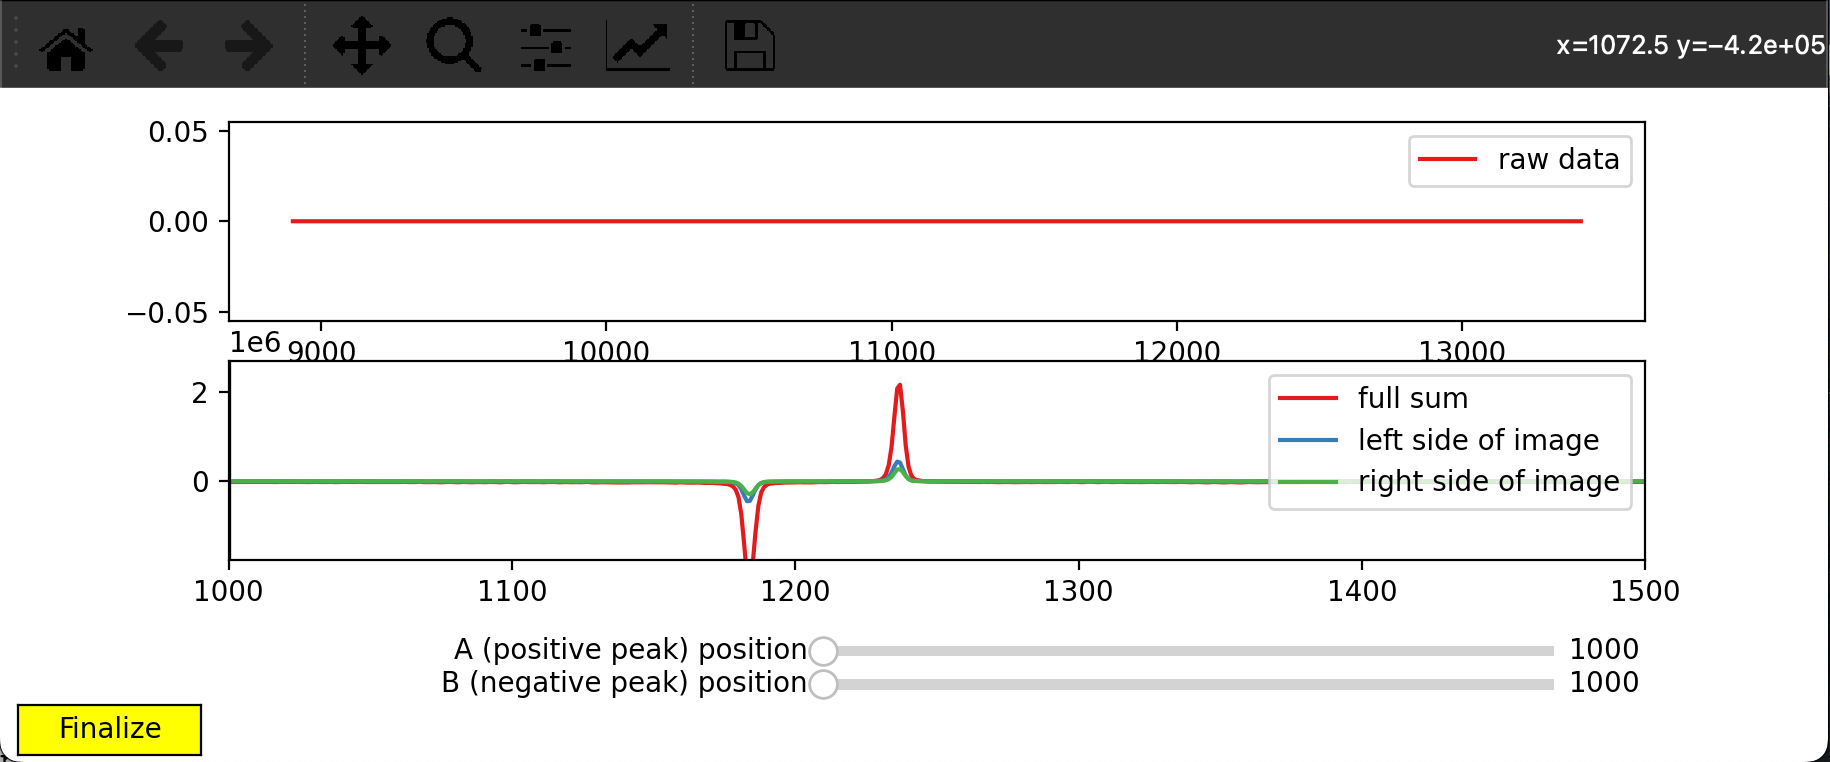


Move the slider to the respective positions, as shown here:

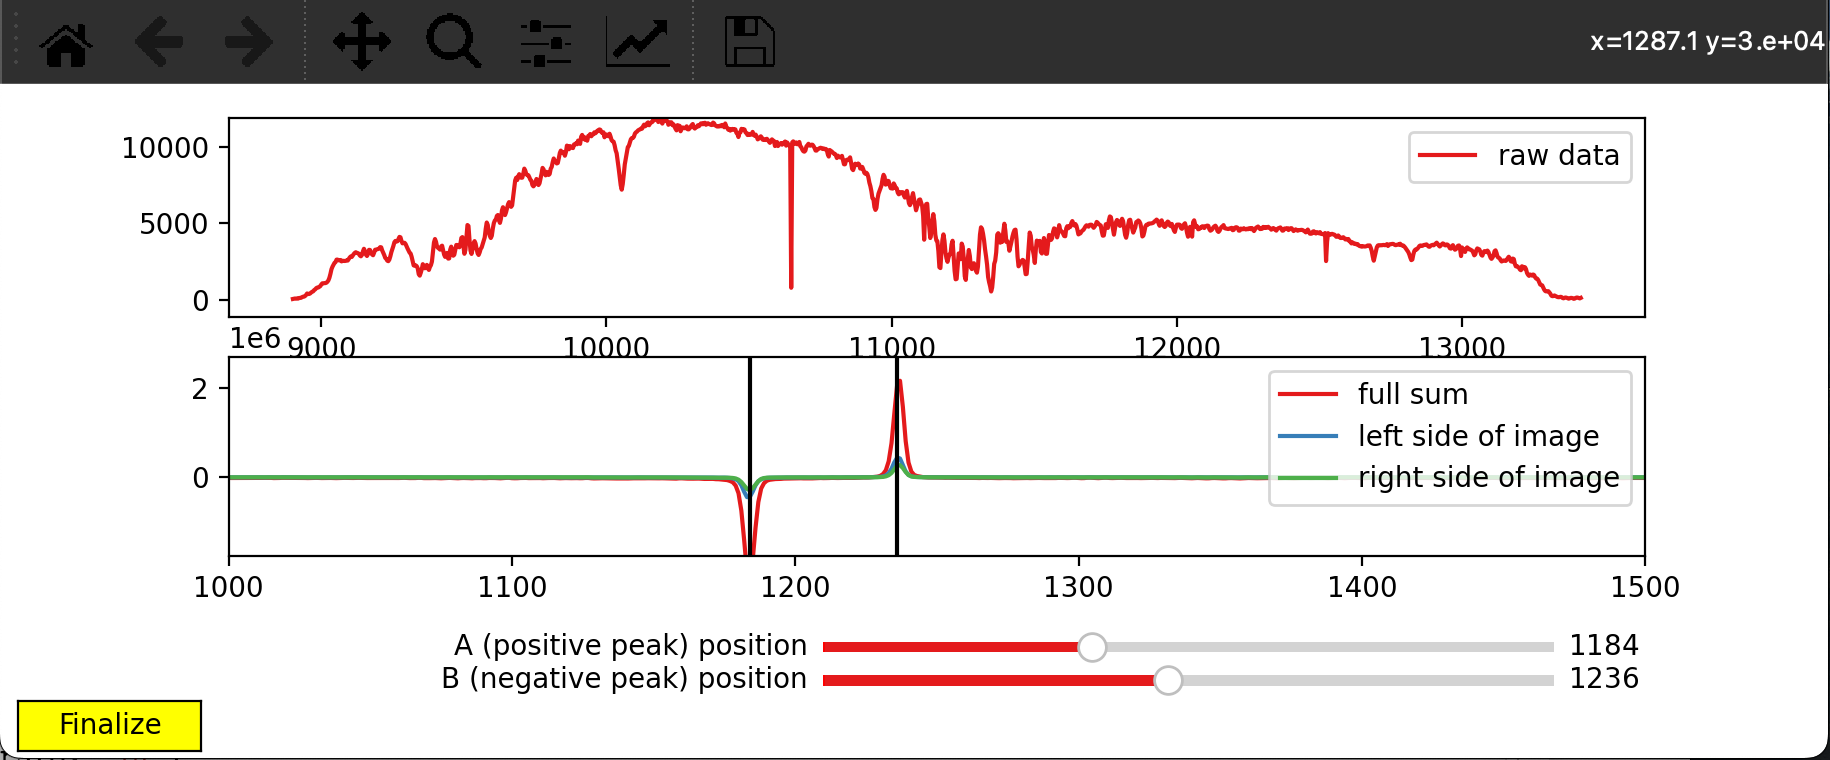

You'll notice that as the slider moves, the upper plot will change based on what the A-B lines look like. Once you are done, click "Finalize" at the bottom left of the screen.

In [3]:
interactive_SN_position_finder(o, GRISM)

(<matplotlib.widgets.Button at 0x17f55d4d0>, {'low': 1184, 'high': 1236})

In [4]:
int_kwargs = get_parameters(o, GRISM)
int_kwargs['SN_position']

(1184, 1236)

__*Note on using Jupyter Notebooks for this module:*__ notice how when I used the `interactive_SN_position_finder` function, I accessed the params in the following box. If I did not, SN_position would be `(1000,1000)` (you can try this to confirm). This is because the `interactive_SN_position_finder` returns the params dictionary before the interactive window is closed. In order to get the values from the sliders in the interactive window, you must close the interactive window and then store the values from params. __*This only happens in notebooks, if you are using the interactive functions within a vanilla python script the execution will pause while you do the interactive input*__

Now we have the A and B positions, it's time to make the response curve. Again, we could do this the way that was done in the previous tutorial, but sometimes this procedure goes wrong. 

This procedure works by creating best-fit lines to the raw and tabulated data, then dividing them to get the response curve. We choose a few (~5) points to create this fit, and these points should by in relatively noiseless, featureless parts of the raw data. Sometimes, the automatic fit chooses very noisy parts of the data, or it lands on a feature. To avoid this, we built an interactive function to choose points on the spectrum to make sure that the response curve is reasonable.

__`interactive_response_curve_fit(o_calib, filter_type, tabulated_flux_path, num_points=5, **kwargs)`__

Interactively finds the sample points for the response curve.

Arguments:

- `o_calib (Obseravation)`: standard star `Observation` object that has the data you want to use
- `filter_type (str)`: the GRISM you want to analyze (options: J, YJ, HK, etc. depending on your quality control file)
- `tabulated_flux_path` (`str`): the path to the .fits file for the standard star
- `num_points` (`int`): number of sample points desired for the fit. Must be greater than 3.
- `kwargs` (`dict`): kwargs for getting and analyzing the spectra. Same options as in `Observation.make_response_curve`, listed below.

Returns:
- params dictionary, with `params['high']` being the A (positive peak) position and `params['low']` being the B (negative peak) position

##### kwargs options:
- `SN_position` (`tuple` or `int`): a tuple of length 2 to specify which y-axis pixels the positive and negative ABBA results are respectively, or an integer with the approximate position of the A and B positions.
- `correct_telluric_lines (bool)`: flag to correct telluric lines. Default: `True`
- `prelim_smooth_radius (int)`: smooth radius for the response curve between the intial and telluric correction steps. Default: `None`
- `telluric_smooth_radius (int)`: smooth radius for the response curve after the telluric correction. Default: `None`
- `raw_debug` (`bool`): flag to output extra information about the raw data selection (launches a matpotlib plot)


When you call `interactive_response_curve_fit` you will get a pop-up window which as 3 or more sliders at the bottom. 

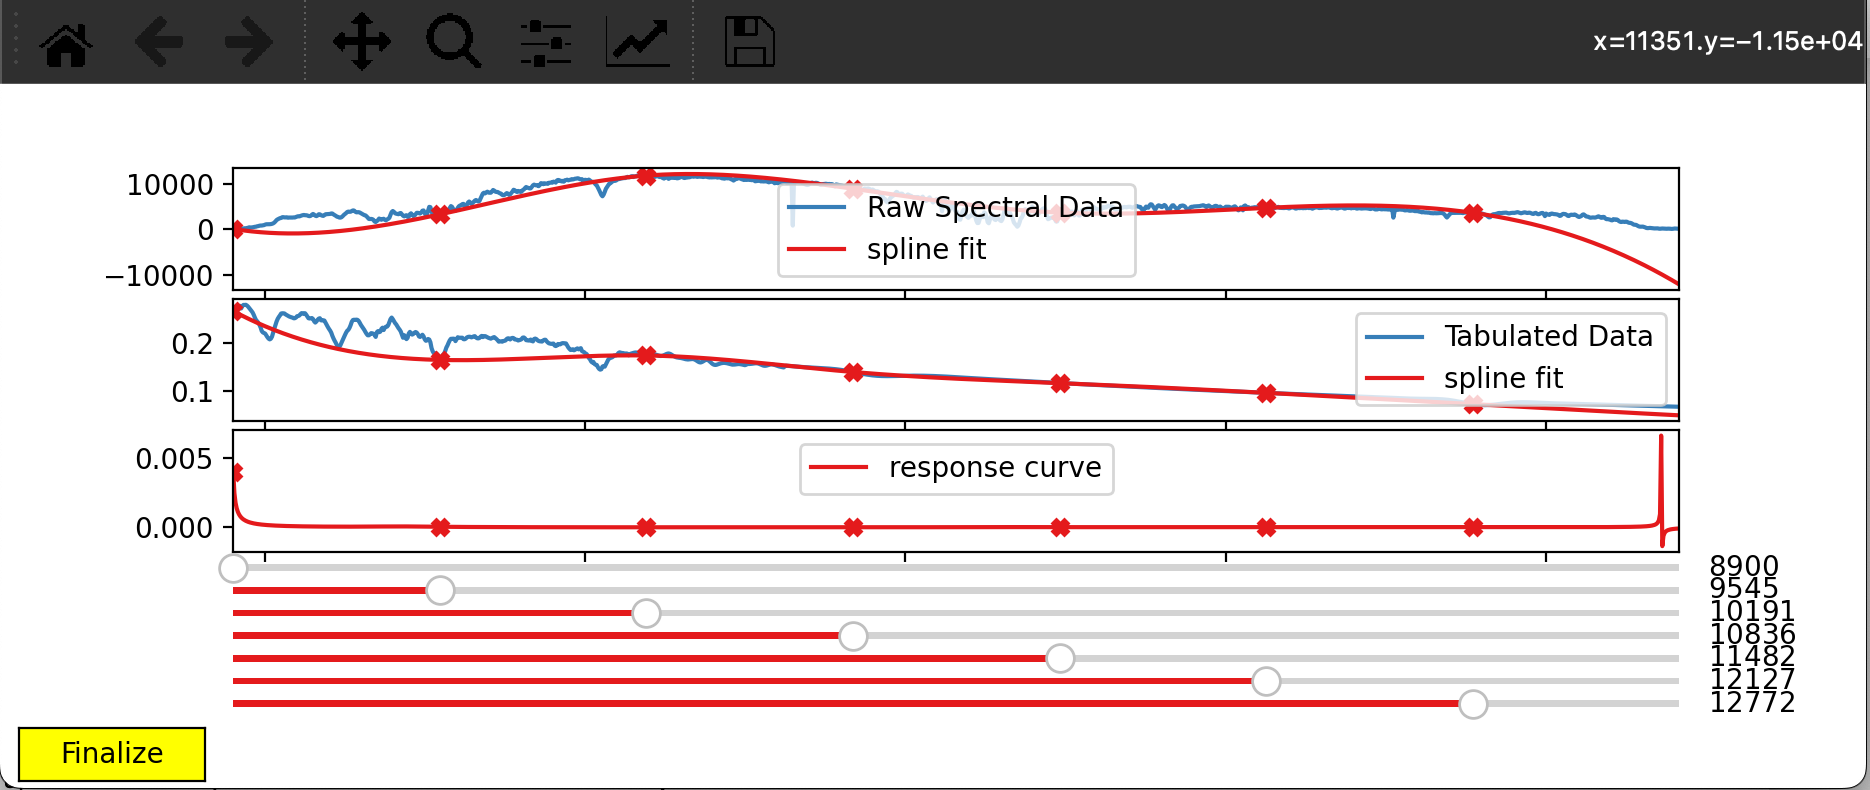



As you slide these around, the points on the top plot (the raw spectrum) and the middle plot (the tabulated spectrum) will update accordingly. As those change, the bottom plot (the response curve) will change as the fits to the points change. 

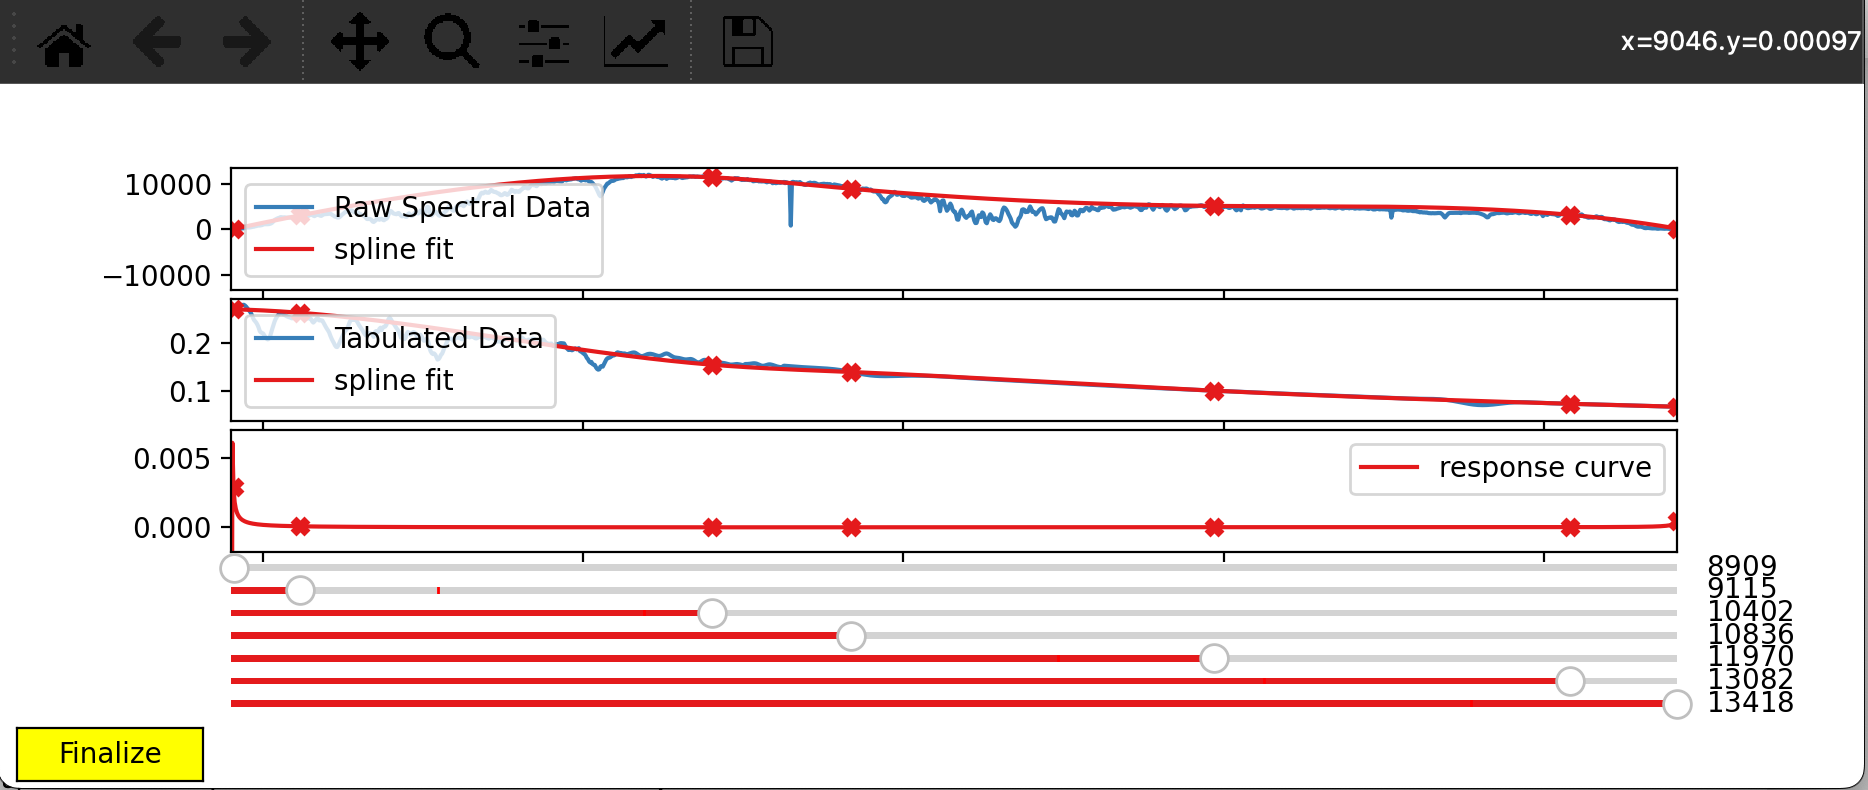


If you want to change the y or x limits of the plot, you can use matplotlib tools as follows:

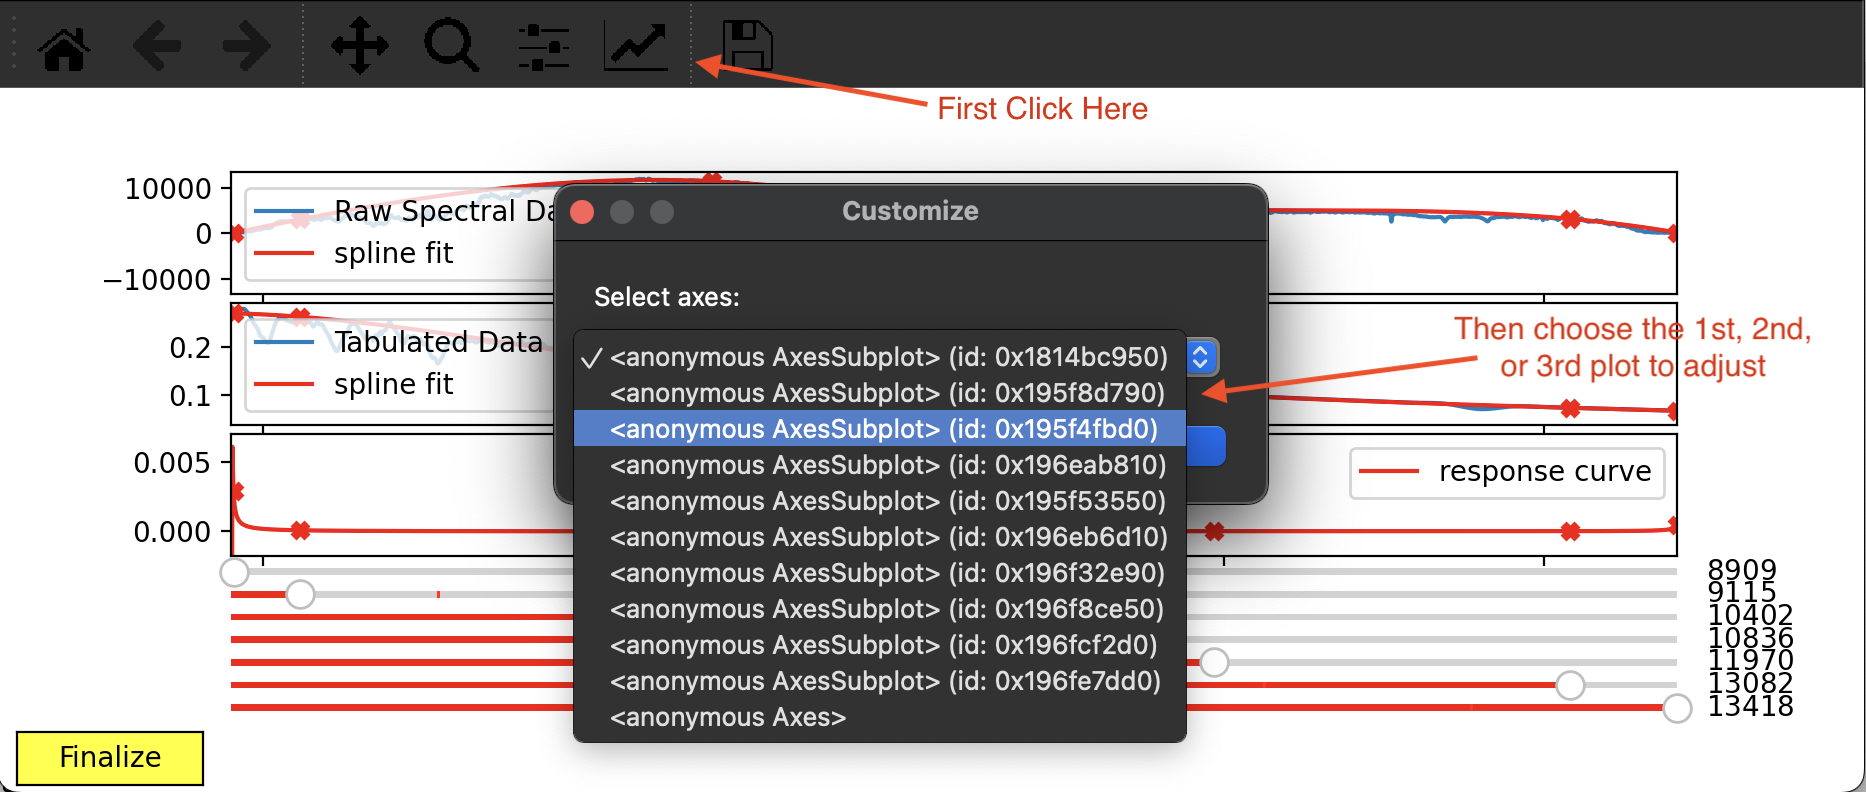


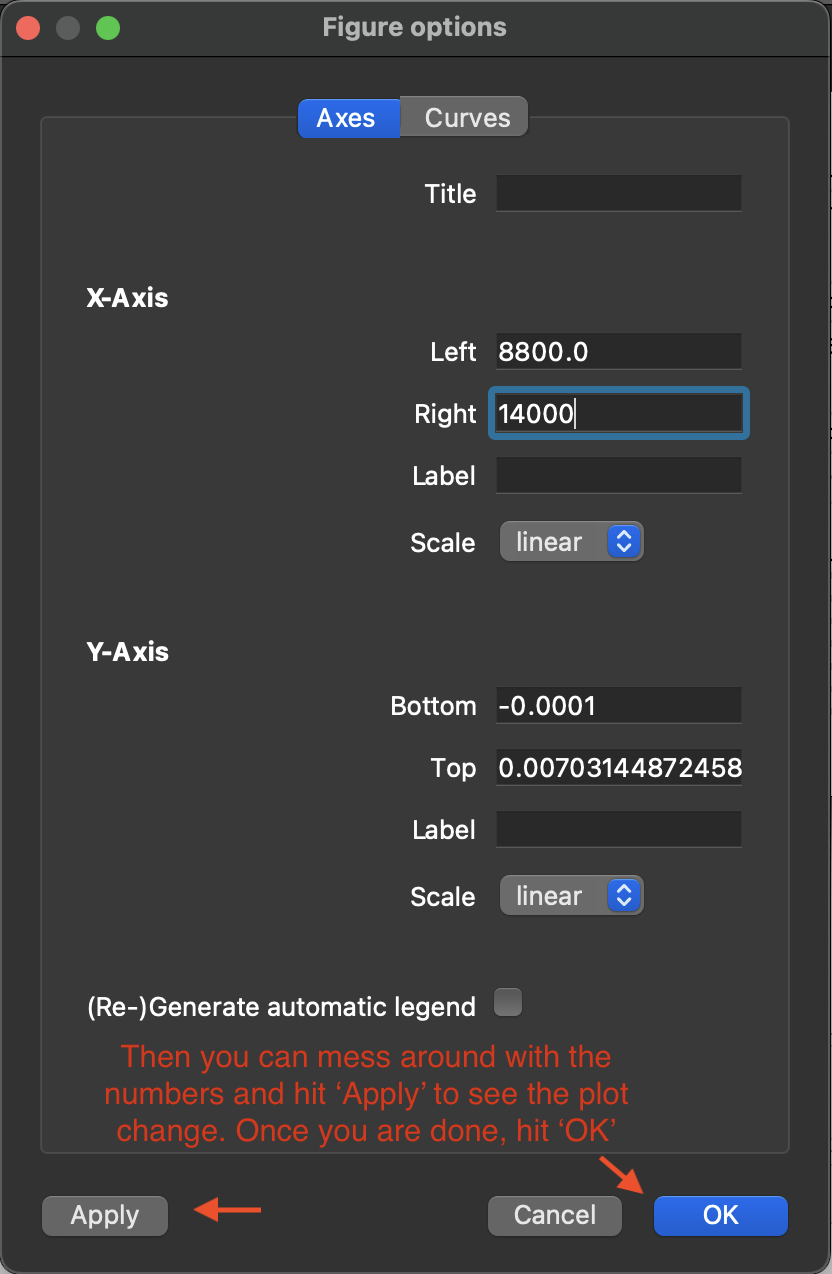

Once you think the response curve looks good, click "Finalize" to save the sample points

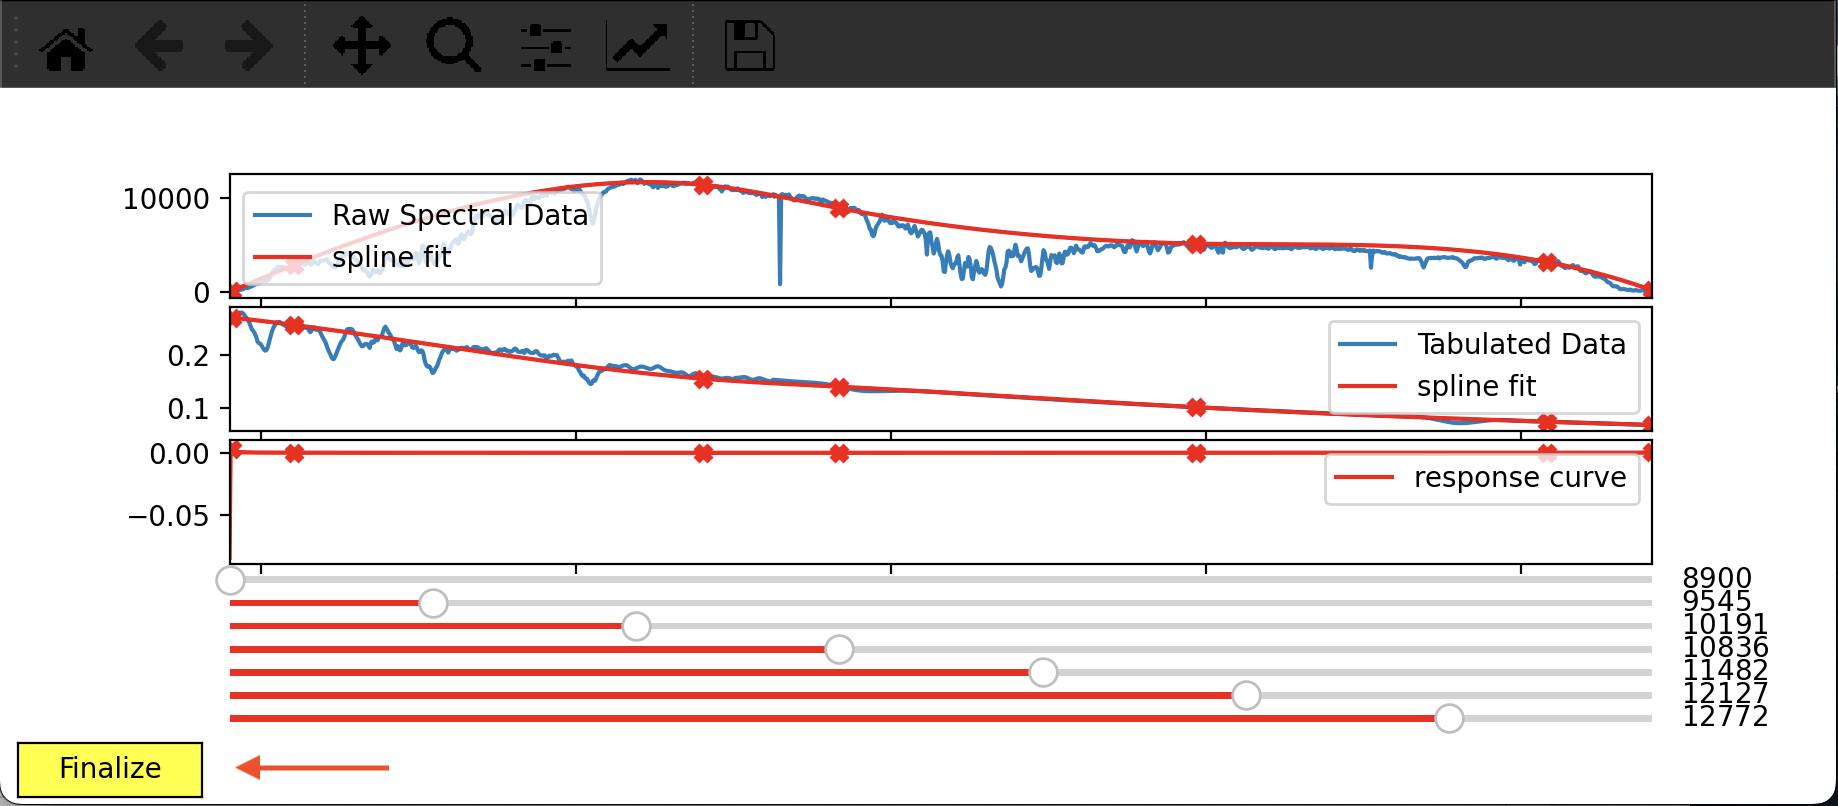

In [5]:
interactive_response_curve_fit(o, GRISM, **int_kwargs)

([<matplotlib.widgets.Button at 0x1946c7e10>,
 {'point 0': <matplotlib.widgets.Slider at 0x180ad05d0>,
  'point 1': <matplotlib.widgets.Slider at 0x180afc750>,
  'point 2': <matplotlib.widgets.Slider at 0x180af8590>,
  'point 3': <matplotlib.widgets.Slider at 0x194628e50>,
  'point 4': <matplotlib.widgets.Slider at 0x1946710d0>,
  'point 5': <matplotlib.widgets.Slider at 0x1946292d0>,
  'point 6': <matplotlib.widgets.Slider at 0x17f5d63d0>})

In [6]:
int_kwargs = get_parameters(o, GRISM)
int_kwargs

{'SN_position': (1184, 1236),
 'sample_points': [8900.0,
  9164.13620967742,
  9464.705,
  9819.922661290322,
  10867.359354838709,
  12315.554435483871,
  13417.64]}

Now, all of the values can be retreived using get_parameters, and you can use these as direct arguments in the `make_response_curve` function, or with anything that takes in `SN_position` or `sample_points` as an argument:

In [8]:
o.make_response_curve(GRISM, **int_kwargs)

Let's make some plots so you can mess around with the parameters:

In [9]:
%matplotlib inline

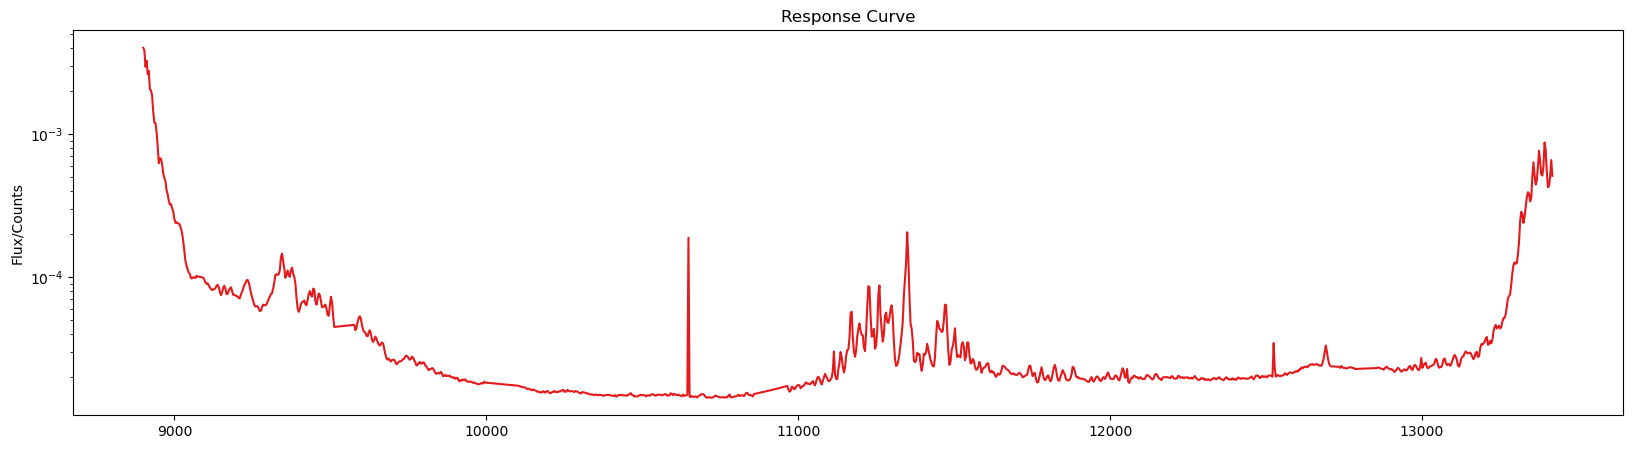

In [10]:
wave, resp = o.get_response_curve(GRISM)

plt.plot(wave, resp)
plt.gcf().set_size_inches((20,5))
plt.yscale('log')

plt.title("Response Curve")
plt.ylabel('Flux/Counts')

plt.show()